# I - ETAPA: TRATAMENTO DE DADOS

In [1]:
# Bibliotecas utilizadas no tratamento dos dados
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Os arquivos, inicialmente integrados, foram baixados separadamente para permitir um tratamento de dados isolado. Essa abordagem evitou a complexidade precoce na base e assegurou uma limpeza mais intuitiva e fluida, resultando em três bases tratadas e ordenadas: 1ª "palavritas_sessions.csv", 2ª "palavritas_attempts.csv" e 3ª "user_profile.csv".

INSEIR O 4ª A UNIÃO DAS BASES

## 1ª Base de dados "palavritas_sessions.csv"

In [2]:
# Carregar os dados do arquivo CSV para um DataFrame do pandas
sessao = pd.read_csv('base_dados_bruto/palavritas_sessions.csv', sep=',')

# Exibir as primeiras linhas do DataFrame para verificar os dados carregados
sessao.head()

,session_id,user_id,word,word_date,attempts,result,time_to_complete_sec,device,session_hour,streak_day,played_next_day,newsletter_open_before_game,active_d30
0,ab38635a07ede4246661,697e9e150e91bb76,TEMPO,2026-02-08,1,win,449,Android,20,2,False,False,False
1,67d40a22cba1a16fd2c5,d7f63dda905adaec,FALHA,2026-05-08,6,lose,232,ios,19,1,True,False,False
2,3635c5707f62ea022423,6220de621fef79b8,FALHA,2026-04-18,3,win,65,iOS,7,2,False,False,False
3,27243d4c7b1669f71ba7,3aa2f6a86d7fe06c,PRATO,2025-12-22,6,lose,404,Android,23,2,False,False,True
4,cd21162dd072f066c160,97af736a7f2aa637,IDEIA,2026-05-28,1,win,222,Android,6,2,False,True,False


**Atribuições das variáveis:** \
session_id = Identificador único da sessão de jogo; \
user_id = Identificador anonimizado do usuário; \
word = Palavra do desafio do dia; \
word_date = Data do desafio; \
attempts = Número de tentativas (1–6); \
result = Resultado: win / lose; \
time_to_complete_sec = Tempo de jogo em segundos; \
device = Dispositivo usado; \
session_hour = Hora do dia em que jogou (0–23); \
streak_day = Dia atual da sequência do usuário; \
played_next_day = Se o usuário voltou a jogar no dia seguinte; \
newsletter_open_before_game = Se abriu a newsletter antes de jogar naquele dia; \
active_d30 = Se o usuário estava ativo 30 dias após essa sessão.

### A) Análise dos tipos de dados, se possuem dados nulos e a quantidade

In [3]:
# Exibir informações sobre o DataFrame, incluindo tipos de dados e contagem de valores não nulos
sessao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   session_id                   41157 non-null  object
 1   user_id                      41157 non-null  object
 2   word                         41157 non-null  object
 3   word_date                    41157 non-null  object
 4   attempts                     41157 non-null  int64 
 5   result                       41094 non-null  object
 6   time_to_complete_sec         41157 non-null  int64 
 7   device                       41157 non-null  object
 8   session_hour                 41157 non-null  int64 
 9   streak_day                   41157 non-null  int64 
 10  played_next_day              41157 non-null  bool  
 11  newsletter_open_before_game  41157 non-null  bool  
 12  active_d30                   41157 non-null  bool  
dtypes: bool(3), int64(4), object(6)

**Análise:** \
A variável "word_date" trata de datas, e está em formato object, logo, necessitara de maior análise para posterior correção. O restante das variáveis apresentam o formato dos dados compativeis com suas atribuições. Vale observar que apenas a variável "result" apresenta valores nulos, o que resultara em uma posterior análise e tratamento.

#### Análise, tratamento e conversão da variável "word_data" para o tipo data

In [4]:
# Conferência dos dados preenchidos da variável "word_date"
sessao['word_date'].unique()

array(['2026-02-08', '2026-05-08', '2026-04-18', '2025-12-22',
       '2026-05-28', '2026-05-25', '2026-03-01', '2025-12-29',
       '19/01/2026', '2026-01-25', '2026-01-14', '2026-02-09',
       '2026-01-12', '2026-01-21', '2026-04-10', '2026-01-23',
       '2025-12-09', '2026-04-01', '13/02/2026', '2026-05-29',
       '2026-03-06', '2026-01-17', '2026-05-11', '2025-12-03',
       '2025-12-24', '2025-12-31', '2026-01-09', '2025-12-10',
       '2026-04-09', '2026-04-06', '2026-02-17', '2026-04-16',
       '2026-01-13', '2026-05-22', '20/01/2026', '2026-02-07',
       '2025-12-17', '2026-04-08', '2026-03-03', '2026-05-07',
       '2026-03-22', '2026-02-21', '07/05/2026', '2026-02-16',
       '2026-05-12', '2026-03-30', '26/03/2026', '2026-03-19',
       '2026-04-30', '2026-04-03', '2026-04-22', '22/05/2026',
       '2026-04-05', '2025-12-23', '2026-02-01', '2026-05-16',
       '2026-02-12', '2026-01-20', '2026-02-04', '2026-05-03',
       '2026-04-07', '20/03/2026', '05/05/2026', '2026-

**Análise:** \
Ao analisar detalhadamente a variável, foi identificado que um dos fatores que impede seu reconhecimento como uma data é a presença de registros em formatos diferentes. Parte dos valores está no padrão brasileiro (DD/MM/AAAA), utilizando barras (/), enquanto outra parte está no padrão ISO (AAAA-MM-DD), utilizando hífens (-). Essa inconsistência impossibilita a correta conversão da coluna para o tipo datetime.

Antes de realizar a conversão, será efetuada a remoção de possíveis espaços em branco no início e no final dos registros, evitando falhas durante o processo de transformação. Em seguida, todos os valores serão convertidos para o tipo datetime, padronizando a variável e permitindo sua utilização nas análises temporais da etapa de EDA.

In [5]:
# Remoção de espaços em branco (prevenção caso haja) no início e no final da variável "word_date"
sessao['word_date'] = sessao['word_date'].astype(str).str.strip()

# Conversão para datetime
sessao['word_date'] = pd.to_datetime(
    sessao['word_date'], 
    format='mixed',
    errors='coerce'  # Isso irá converter valores inválidos para NaT (Not a Time)
)

In [6]:
# Conferência dos dados preenchidos da variável "word_date" após a conversão
sessao['word_date'].unique()

<DatetimeArray>
['2026-02-08 00:00:00', '2026-05-08 00:00:00', '2026-04-18 00:00:00',
 '2025-12-22 00:00:00', '2026-05-28 00:00:00', '2026-05-25 00:00:00',
 '2026-03-01 00:00:00', '2025-12-29 00:00:00', '2026-01-19 00:00:00',
 '2026-01-25 00:00:00',
 ...
 '2026-07-01 00:00:00', '2025-06-12 00:00:00', '2026-11-05 00:00:00',
 '2025-05-12 00:00:00', '2026-08-05 00:00:00', '2026-09-03 00:00:00',
 '2026-10-04 00:00:00', '2026-12-05 00:00:00', '2026-11-03 00:00:00',
 '2026-10-01 00:00:00']
Length: 226, dtype: datetime64[ns]

**Análise:** \
Após a conversão, a variável passou a exibir também o horário (00:00:00). Como a base de dados não contém informações de hora vinculado a data, esse componente não possui relevância para as análises. Ainda assim, ele será mantido, pois faz parte do tipo datetime do pandas e garante maior flexibilidade para manipulações e análises temporais futuras.

In [7]:
# Conferência do formato da variável "word_date" após a conversão
sessao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   session_id                   41157 non-null  object        
 1   user_id                      41157 non-null  object        
 2   word                         41157 non-null  object        
 3   word_date                    41157 non-null  datetime64[ns]
 4   attempts                     41157 non-null  int64         
 5   result                       41094 non-null  object        
 6   time_to_complete_sec         41157 non-null  int64         
 7   device                       41157 non-null  object        
 8   session_hour                 41157 non-null  int64         
 9   streak_day                   41157 non-null  int64         
 10  played_next_day              41157 non-null  bool          
 11  newsletter_open_before_game  41157 non-nu

#### Análise e tratamento de valores nulos da variável "result"

In [8]:
# Conferência da quantidade de dados nulos da variável "result"
quantidade_nulos = sessao['result'].isnull().sum()

print(f'Quantidade de valores nulos da variável "result": {quantidade_nulos}')

Quantidade de valores nulos da variável "result": 63


In [9]:
# Conferência do percentual de dados nulos da variável "result"
percentual_nulos = sessao['result'].isnull().mean() * 100

print(f'Percentual de valores nulos da variável "result": {percentual_nulos:.2f}%')

Percentual de valores nulos da variável "result": 0.15%


**Análise:** \
A variável possui cerca de 0,15% de valores nulos. Devido à baixa ocorrência desses registros, eles serão removidos, pois seu impacto sobre a base de dados é considerado desprezível.

In [10]:
# Exclusão de linhas com valores nulos na variável "result"
sessao = sessao.dropna(subset=['result'])

In [11]:
# Conferência dos valores nulos após a exclusão
sessao.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41094 entries, 0 to 41156
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   session_id                   41094 non-null  object        
 1   user_id                      41094 non-null  object        
 2   word                         41094 non-null  object        
 3   word_date                    41094 non-null  datetime64[ns]
 4   attempts                     41094 non-null  int64         
 5   result                       41094 non-null  object        
 6   time_to_complete_sec         41094 non-null  int64         
 7   device                       41094 non-null  object        
 8   session_hour                 41094 non-null  int64         
 9   streak_day                   41094 non-null  int64         
 10  played_next_day              41094 non-null  bool          
 11  newsletter_open_before_game  41094 non-null  b

### B) Análise e padronização do preenchimento das variáveis

A análise de preenchimento será realizada apenas nas variáveis do tipo object, desconsiderando as colunas que atuam como identificadores. As variáveis dos tipos data, int e bool também não serão analisadas, pois já se encontram padronizadas, armazenadas no tipo de dado adequado e não apresentam necessidade de avaliação quanto ao preenchimento nesta etapa.

In [12]:
# Variáveis que serão analisadas "word", "result" e "device"
a1 = sessao['word'].unique()
a2 = sessao['result'].unique()
a3 = sessao['device'].unique()

print(f'Valores únicos da variável "word":\n {a1}\n')
print(f'Valores únicos da variável "result":\n {a2}\n')
print(f'Valores únicos da variável "device":\n {a3}\n')

Valores únicos da variável "word":
 ['TEMPO' 'FALHA' 'PRATO' 'IDEIA' 'NUVEM' 'DANÇA' 'BARCO' 'PLANO' 'CORVO'
 'TROCO' 'GENRO' 'METAL' 'VINHO' 'HERÓI' 'PRETO' 'VENTO' 'MORRO' 'FRACO'
 'NIXÃO' 'CIÚME' 'PAZÃO' 'JOGOS' 'CAMPO' 'FILME' 'CASCA' 'PRAIA' 'SONHO'
 'LARGO' 'ORAÇÃ' 'ROSTO']

Valores únicos da variável "result":
 ['win' 'lose']

Valores únicos da variável "device":
 ['Android' 'ios' 'iOS' 'android' 'IOS' 'ANDROID']



**Análise:** \
Foi identificado que a variável "device" apresenta categorias iguais registradas com diferenças nas letras, com maiúsculas e minúsculas, fazendo com que o mesmo dispositivo seja interpretado como categorias distintas. Para garantir a consistência dos dados e evitar duplicidade de categorias durante as análises, será realizada a padronização dos valores.

Além disso, observou-se que a variável "result" possui seus registros preenchidos em letras minúsculas, diferindo do padrão adotado nas demais variáveis categóricas. Assim, seus valores também serão padronizados, visando manter a uniformidade e a legibilidade da base de dados.

In [13]:
# Correção dos valores da variável "result" para padronização
sessao['result'] = sessao['result'].replace({
    'win': 'Win',
    'lose': 'Lose',
})

# Correção das categorias da variável "device" para padronização
sessao['device'] = sessao['device'].replace({
    'android': 'Android',
    'ANDROID': 'Android',
    'ios': 'iOS',
    'IOS': 'iOS',
})

In [14]:
# Verificação da padronização dos valores das variáveis "result" e "device"
a1 = sessao['result'].unique()
a2 = sessao['device'].unique()

print(f'Valores únicos da variável "result":\n {a1}\n')
print(f'Valores únicos da variável "device":\n {a2}\n')

Valores únicos da variável "result":
 ['Win' 'Lose']

Valores únicos da variável "device":
 ['Android' 'iOS']



### C) Análise mais precisa de valores nulos, faltantes e outliers (valores discrepantes)

In [15]:
# Verificação de valores nulos e faltantes
sessao.isnull().sum()

session_id                     0
user_id                        0
word                           0
word_date                      0
attempts                       0
result                         0
time_to_complete_sec           0
device                         0
session_hour                   0
streak_day                     0
played_next_day                0
newsletter_open_before_game    0
active_d30                     0
dtype: int64

In [16]:
# Verificação de outliers (valores discrepantes)
sessao.describe()

,word_date,attempts,time_to_complete_sec,session_hour,streak_day
count,41094,41094.000000,41094.000000,41094.000000,41094.000000
mean,2026-03-03 21:09:46.070959360,3.583735,269.831411,15.147783,1.292378
min,2025-01-12 00:00:00,0.000000,60.000000,6.000000,1.000000
25%,2026-01-15 00:00:00,2.000000,164.000000,8.000000,1.000000
50%,2026-03-02 00:00:00,3.000000,269.000000,17.000000,1.000000
75%,2026-04-19 00:00:00,6.000000,375.000000,21.000000,1.000000
max,2026-12-05 00:00:00,8.000000,480.000000,23.000000,8.000000
std,NaN,2.063170,121.808822,6.213868,0.631086


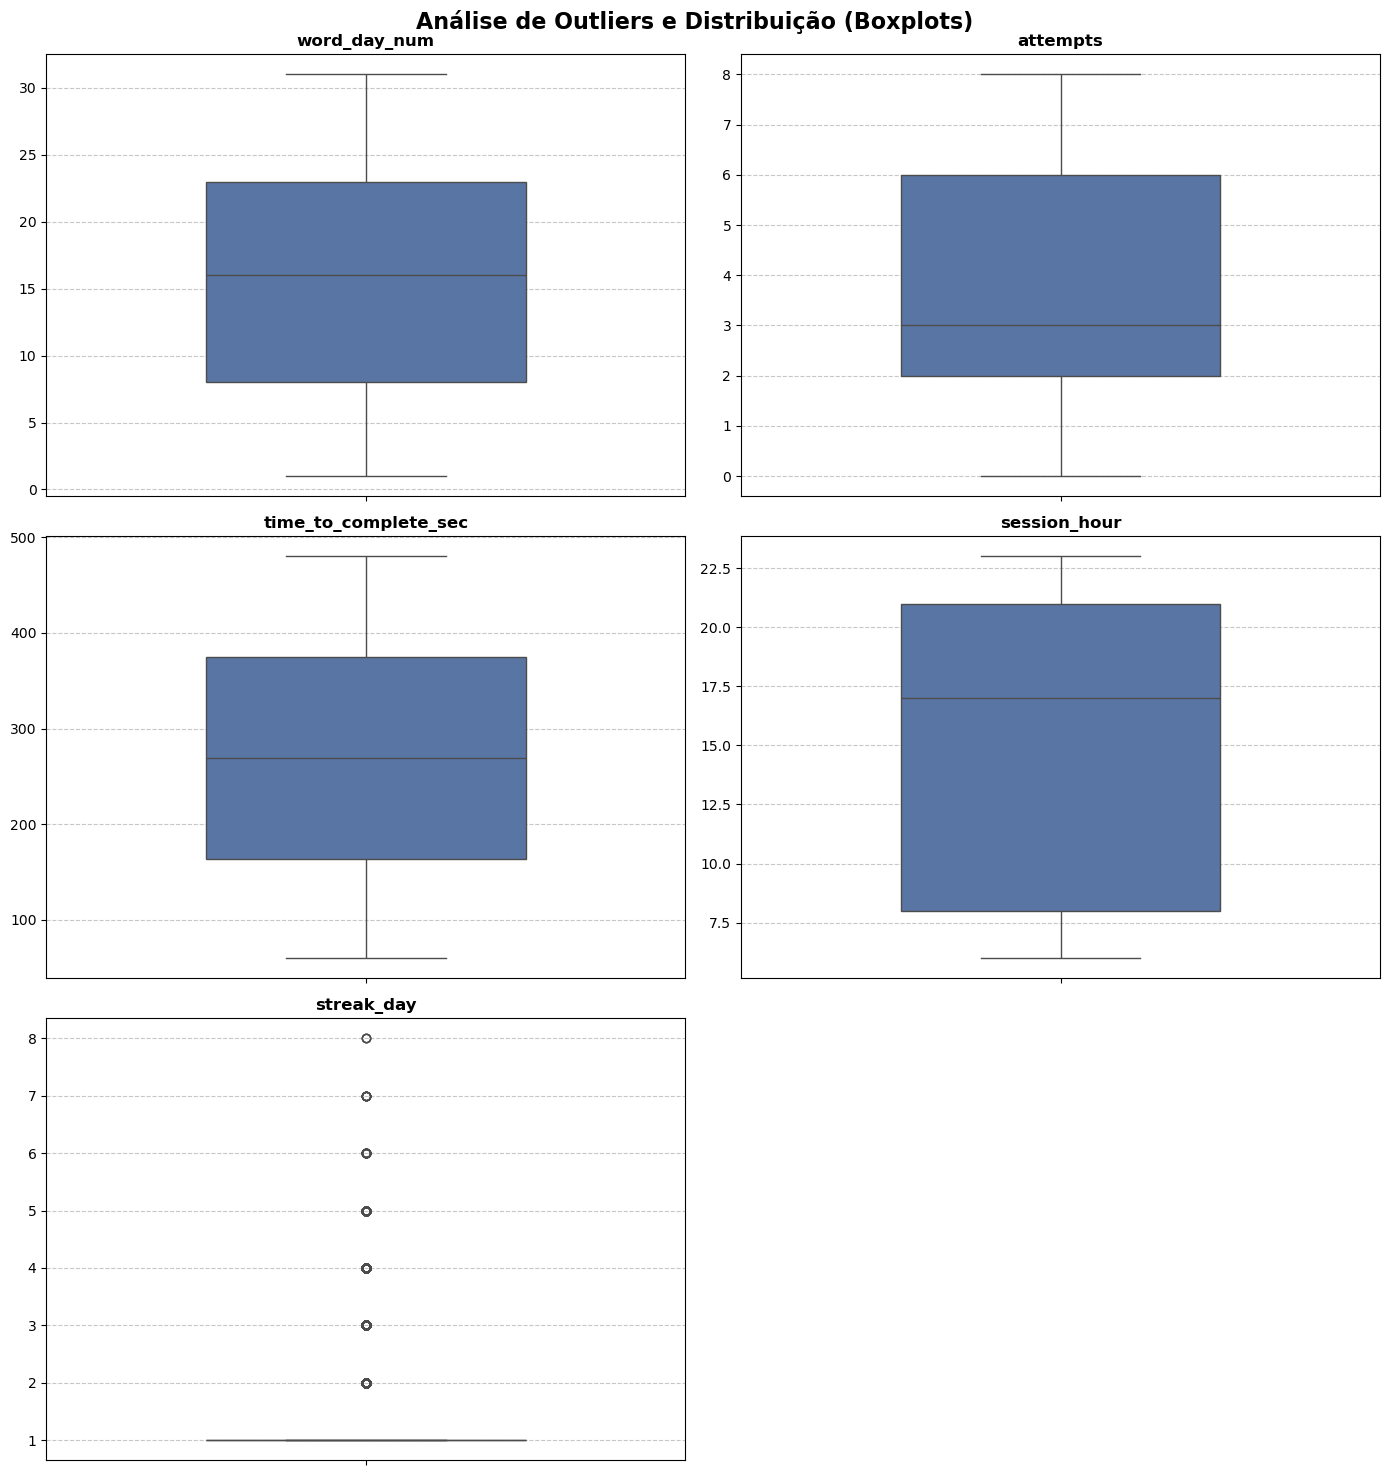

In [17]:
# Boxplot para análise de outliers e distribuição das variáveis numéricas
# Extrair o dia da coluna "word_date"
sessao['word_day_num'] = sessao['word_date'].dt.day  # Extrai o dia do mês (1 a 31)

# Lista com as colunas numéricas para o Boxplot
colunas_analise = ['word_day_num', 'attempts', 'time_to_complete_sec', 'session_hour', 'streak_day']

# Configurar a estrutura dos gráficos (3 linhas com 2 colunas)
# Dica: Aumentei o figsize para 15 de altura para os 3 blocos não ficarem esmagados
fig, axes = plt.subplots(3, 2, figsize=(14, 15)) 
fig.suptitle('Análise de Outliers e Distribuição (Boxplots)', fontsize=16, fontweight='bold')

# .flatten() transforma a matriz 3x2 em uma lista linear de 6 posições
axes_flat = axes.flatten()

# Gerar Boxplot para cada coluna
for i, col in enumerate(colunas_analise):
    sns.boxplot(y=sessao[col], ax=axes_flat[i], color='#4C72B0', width=0.5)
    axes_flat[i].set_title(col, fontsize=12, fontweight='bold')
    axes_flat[i].set_ylabel('')  # Limpa o eixo Y
    axes_flat[i].grid(axis='y', linestyle='--', alpha=0.7)

# Como temos 5 gráficos para 6 espaços, removemos o último quadrante vazio
fig.delaxes(axes_flat[-1])

# Ajusta o espaçamento para não cortar nada
plt.tight_layout()
plt.show()

**Análise:** \
Após a conclusão do tratamento dos dados, constata-se que a base não possui mais valores nulos ou ausentes. A análise dos valores extremos, realizada por meio de boxplots, também não identificou outliers que justificassem intervenção, indicando que a base está consistente e preparada para as etapas seguintes de finalização de tratamento e posterior análise exploratoria de dados.

## 2ª Base de dados "palavritas_attempts.csv"

In [18]:
# Carregar os dados do arquivo CSV para um DataFrame do pandas
palavritas = pd.read_csv('base_dados_bruto/palavritas_attempts.csv', sep=',')

# Exibir as primeiras linhas do DataFrame para verificar os dados carregados
palavritas.head()

,session_id,attempt_number,guess,correct_letters,correct_positions
0,ab38635a07ede4246661,1,TEMPO,0,5
1,67d40a22cba1a16fd2c5,1,NOVAS,1,0
2,67d40a22cba1a16fd2c5,2,OUVIR,0,0
3,67d40a22cba1a16fd2c5,3,NOVAS,1,0
4,67d40a22cba1a16fd2c5,4,VAPOR,0,1


**Atribuições das variáveis:** \
session_id = FK para sessions; \
attempt_number = Número da tentativa; \
guess = Palavra digitada; \
correct_letters = Letras certas em posição errada; \
correct_positions = Letras certas na posição certa.

### A) Análise dos tipos de dados, se possuem dados nulos e a quantidade

In [19]:
# Exibir informações sobre o DataFrame, incluindo tipos de dados e contagem de valores não nulos
palavritas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147270 entries, 0 to 147269
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   session_id         147270 non-null  object
 1   attempt_number     147270 non-null  int64 
 2   guess              147270 non-null  object
 3   correct_letters    147270 non-null  int64 
 4   correct_positions  147270 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 5.6+ MB


**Análise:** \
A análise inicial demonstra que todas as variáveis possuem tipos de dados compatíveis e não apresentam valores nulos. Ainda assim, será realizada uma análise mais detalhada do conteúdo de cada coluna para verificar possíveis inconsistências de preenchimento ou padronização.

### B) Análise e padronização do preenchimento das variáveis

A análise focará apenas na variável "guess", seguindo o mesmo critério de tratamento de dados da base 
"palavritas_sessions.csv".

In [20]:
# Verificação de valores preenchidos
palavritas['guess'].unique()

array(['TEMPO', 'NOVAS', 'OUVIR', 'VAPOR', 'JOGAR', 'OUTRA', 'GOLPE',
       'MANGA', 'FALHA', 'LENTO', 'FICHA', 'TROÇA', 'HERÓI', 'ACHAR',
       'USADO', 'IDEIA', 'SENDO', 'NUNCA', 'SOBRE', 'GESTO', 'BURRO',
       'MUITO', 'RAZÃO', 'DANÇA', 'IMAGE', 'PRATO', 'BARCO', 'PLANO',
       'CORVO', 'URGIR', 'TROCO', 'POMBO', 'PODER', 'GENRO', 'LUGAR',
       'GREVE', 'MILHO', 'SALVO', 'VAZIO', 'NUVEM', 'NOBRE', 'METAL',
       'BAIXO', 'XEQUE', 'MEIOS', 'OLHOS', 'FILHO', 'NEGRO', 'VINHO',
       'RISCO', 'BRADO', 'BEIRA', 'IMÓVE', 'HAVIA', 'ESTÃO', 'ONDAS',
       'AINDA', 'PRETO', 'XAMPU', 'MUNDO', 'GRUPO', 'IDADE', 'IRÔNI',
       'VENTO', 'RAIVA', 'MORRO', 'OFERT', 'TUMOR', 'IGUAL', 'FRACO',
       'CORTE', 'ELETR', 'VERBO', 'COURO', 'GRADE', 'SOPRO', 'WAGON',
       'FALSO', 'ABRIR', 'ZUMBI', 'UNIDO', 'VIRAR', 'AUTOR', 'DEVEM',
       'NERVO', 'DELTA', 'MAGRO', 'INVÉS', 'SUAVE', 'SABOR', 'MOLHO',
       'HABIT', 'HASTE', 'LANCE', 'QUERO', 'ETAPA', 'CESTA', 'METOD',
       'ZEBRA', 'ÚNI

**Análise:** \
É perceptível que todas as palavras estão padronizadas em um formato único. Como essa variável armazena os termos digitados pelos usuários, ela apresenta uma grande variedade de palavras, conforme o esperado para essa dinâmica.

### C) Análise mais precisa de valores nulos, faltantes e outliers (valores discrepantes)

In [21]:
# Verificação de valores nulos e faltantes
palavritas.isnull().sum()

session_id           0
attempt_number       0
guess                0
correct_letters      0
correct_positions    0
dtype: int64

In [22]:
# Verificação de outliers (valores discrepantes)
palavritas.describe()

,attempt_number,correct_letters,correct_positions
count,147270.000000,147270.000000,147270.000000
mean,2.885387,0.699627,1.305276
std,1.698196,0.843371,1.788985
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,2.000000,0.000000,1.000000
75%,4.000000,1.000000,2.000000
max,10.000000,4.000000,5.000000


KeyError: 'attempt_number'

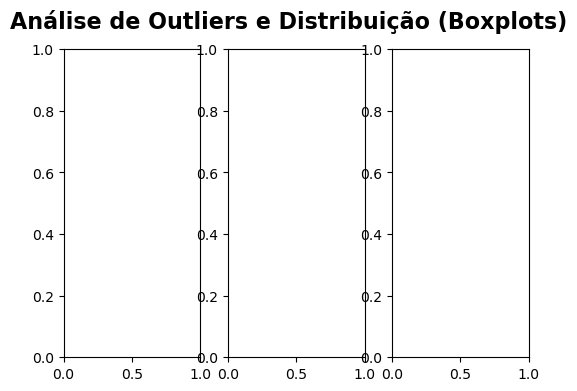

In [23]:
# Boxplot para análise de outliers e distribuição das variáveis numéricas
# Lista com as colunas numéricas para o Boxplot
colunas_analise = ['attempt_number', 'correct_letters', 'correct_positions']

# Configurar a estrutura dos gráficos (1 linhas com 3 colunas)
# Dica: Aumentei o figsize para 15 de altura para os 3 blocos não ficarem esmagados
fig, axes = plt.subplots(1, 3, figsize=(6, 4)) 
fig.suptitle('Análise de Outliers e Distribuição (Boxplots)', fontsize=16, fontweight='bold')

# .flatten() transforma a matriz 1x3 em uma lista linear de 3 posições
axes_flat = axes.flatten()

# Gerar Boxplot para cada coluna
for i, col in enumerate(colunas_analise):
    sns.boxplot(y=sessao[col], ax=axes_flat[i], color='#4C72B0', width=0.5)
    axes_flat[i].set_title(col, fontsize=12, fontweight='bold')
    axes_flat[i].set_ylabel('')  # Limpa o eixo Y
    axes_flat[i].grid(axis='y', linestyle='--', alpha=0.7)

# Como temos 3 gráficos para 3 espaços, não precisamos remover nenhum quadrante
# fig.delaxes(axes_flat[-1])

# Ajusta o espaçamento para não cortar nada
plt.tight_layout()
plt.show()

**Análise:** \
Após a análise dos dados, constata-se que a base não precisa de tratamento. Os outliers que aparecem nas variáveis "attempt_number" e "correct_letters" no boxplot não demonstram erros de registro, mas sim comportamentos reais dos usuários.

## 3ª Base de dados "user_profile.csv"

In [24]:
# Carregar os dados do arquivo CSV para um DataFrame do pandas
usuarios = pd.read_csv('base_dados_bruto/user_profile.csv', sep=',')

# Exibir as primeiras linhas do DataFrame para verificar os dados carregados
usuarios.head()

,user_id,age_range,state,city,salary_range,job_role,sector,company_size,orders_food_delivery,food_delivery_freq_week,food_delivery_platform,primary_device,plays_other_word_games,typical_play_time,newsletter_subscriber
0,fe2e4f159653f26f,NaN,MG,NaN,R$4k-R$6k,Consultor,finanças,pequena,True,5,Rappi,Android,True,afternoon,True
1,4d89d721da20cbc3,35-44,MG,Rio de Janeiro,R$4k-R$6k,analista,educação,multinacional,True,3,Ambos,iOS,True,morning,True
2,91bf47f1274e23a8,25-34,PB,NaN,NaN,Coordenador,tech,pequena,True,3,Nenhum,Android,True,morning,True
3,4efe31b67538c37f,25-34,PB,NaN,até R$2k,Gerente,finanças,grande,True,5,Nenhum,iOS,False,afternoon,False
4,d6af92f33a83c685,18-24,RN,Belo Horizonte,até R$2k,consultor,outros,pequena,False,0,Nenhum,Android,True,evening,False


**Atribuições das variáveis:** \
user_id = FK para sessions; \
age_range = Faixa etária; \
state = Estado (UF); \
city = Cidade; \
salary_range = Faixa salarial; \
job_role = Cargo; \
sector = Setor de trabalho; \
company_size = Porte da empresa; \
orders_food_delivery = Se pede comida por app; \
food_delivery_freq_week = Quantas vezes por semana; \
food_delivery_platform = Plataforma usada; \
primary_device = Dispositivo principal; \
plays_other_word_games = Se joga outros jogos de palavras; \
typical_play_time = Período típico de jogo (morning/afternoon/evening/night); \
newsletter_subscriber = Se é assinante da newsletter.

### A) Análise dos tipos de dados, se possuem dados nulos e a quantidade

In [25]:
# Exibir informações sobre o DataFrame, incluindo tipos de dados e contagem de valores não nulos
usuarios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   user_id                  800 non-null    object
 1   age_range                683 non-null    object
 2   state                    800 non-null    object
 3   city                     503 non-null    object
 4   salary_range             607 non-null    object
 5   job_role                 800 non-null    object
 6   sector                   800 non-null    object
 7   company_size             800 non-null    object
 8   orders_food_delivery     800 non-null    object
 9   food_delivery_freq_week  800 non-null    int64 
 10  food_delivery_platform   800 non-null    object
 11  primary_device           800 non-null    object
 12  plays_other_word_games   800 non-null    bool  
 13  typical_play_time        800 non-null    object
 14  newsletter_subscriber    800 non-null    b

**Análise:** \
Entre todas as variáveis, apenas "orders_food_delivery" apresenta um tipo inconsistente, já que deveria ser booleana, ela será analisada e tratada posteriormente. Além disso, as variáveis "age_range", "city" e "salary_range" possuem dados nulos.

#### Análise, tratamento e conversão da variável "orders_food_delivery" para o tipo booleano

In [26]:
# Análise de padronização e preenchimento da variável
usuarios['orders_food_delivery'].unique()

array(['True', 'False', 'sim', 'não'], dtype=object)

**Análise** \
É possível identificar que a variável apresenta inconsistências de idioma e formatação, misturando termos em inglês com a inicial maiúscula ('True', 'False'), padrão do formato booleano e respostas em português em letras minúsculas ('sim', 'não'). Para converter para o tipo booleano é necessário primeiro deixar tudo no termo inglês.

In [27]:
# Padronização dos termos
usuarios['orders_food_delivery'] = usuarios['orders_food_delivery'].replace({
    'sim': 'True',
    'não': 'False',
})

In [28]:
# Verificação da padronização
usuarios['orders_food_delivery'].unique()

array(['True', 'False'], dtype=object)

In [29]:
# Converão da variável para o tipo booleano
usuarios['orders_food_delivery'] = usuarios['orders_food_delivery'].astype(bool)

In [30]:
# Verificação do tipo de variável após conversão
usuarios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   user_id                  800 non-null    object
 1   age_range                683 non-null    object
 2   state                    800 non-null    object
 3   city                     503 non-null    object
 4   salary_range             607 non-null    object
 5   job_role                 800 non-null    object
 6   sector                   800 non-null    object
 7   company_size             800 non-null    object
 8   orders_food_delivery     800 non-null    bool  
 9   food_delivery_freq_week  800 non-null    int64 
 10  food_delivery_platform   800 non-null    object
 11  primary_device           800 non-null    object
 12  plays_other_word_games   800 non-null    bool  
 13  typical_play_time        800 non-null    object
 14  newsletter_subscriber    800 non-null    b

### B) Análise e padronização do preenchimento das variáveis

Seguindo os criterios utilizados nas análises das bases de dados anteriores, as variáveis que não serão análisadas serão: user_id, orders_food_delivery, food_delivery_freq_week, plays_other_word_games e newsletter_subscriber.

In [31]:
# Variáveis que serão analisadas "age_range", "state", "city", "salary_range", "job_role", "sector", "company_size",
# "food_delivery_platform", "primary_device" e "typical_play_time"
# Lista com as variáveis que não serão analisadas
usuarios_limpos = usuarios.drop(columns=[
    'user_id', 'orders_food_delivery', 'food_delivery_freq_week', 
    'plays_other_word_games', 'newsletter_subscriber'
])

# Verificação e exibição da padronização do preenchimento dos valores das variáveis
for x in usuarios_limpos.columns:
    print(f'Valores únicos da variável "{x}":')
    print(usuarios_limpos[x].unique(), '\n')

Valores únicos da variável "age_range":
[nan '35-44' '25-34' '18-24' '45+'] 

Valores únicos da variável "state":
['MG' 'PB' 'RN' 'PE' 'MS' 'SC' 'AL' 'GO' 'RJ' 'AM' 'CE' 'PR' 'MA' 'SP'
 'RS' 'MT' 'BA' 'SE' 'São Paulo' 'DF' 'ES' 'Minas Gerais'] 

Valores únicos da variável "city":
[nan 'Rio de Janeiro' 'Belo Horizonte' 'Brasília' 'Curitiba' 'São Paulo'
 'Porto Alegre'] 

Valores únicos da variável "salary_range":
['R$4k-R$6k' nan 'até R$2k' 'R$2k-R$4k' 'acima de R$10k' 'R$6k-R$10k'] 

Valores únicos da variável "job_role":
['Consultor' 'analista' 'Coordenador' 'Gerente' 'consultor'
 'Consultor Sênior' 'desenvolvedor' 'Estudante' 'Analista' 'professor'
 'coordenador' 'Designer' 'estudante' 'Diretor de Dados'
 'Consultor de Dados' 'Professor' 'Desenvolvedor Sênior' 'Desenvolvedor'
 'Gerente de Dados' 'engenheiro' 'diretor' 'Coordenador de Dados'
 'designer' 'Engenheiro' 'Engenheiro de Dados' 'Designer Sênior' 'Diretor'
 'Engenheiro Sênior' 'Gerente Sênior' 'Analista Sênior' 'gerente'
 'Di

**Análise:** \
Ao analisar as variáveis, observa-se que "state" e "job_role" necessitam de correção no preenchimento. A variável "typical_play_time" exige tanto a correção de preenchimento quanto a padronização de seu formato. Por fim, as variáveis "sector" e "company_size" demandam apenas a padronização para seguir o padrão da base de dados.

#### Correção de preenchimento das variáveis "state" e "job_role" e padronização de "typical_play_time", "sector" e "company_size"

In [32]:
# Correção dos valores das variáveis "state" e "job_role"
usuarios['state'] = usuarios['state'].replace({
    'São Paulo': 'SP',
    'Minas Gerais': 'MG'
})

usuarios['job_role'] = usuarios['job_role'].replace({
    'analista': 'Analista', 'consultor': 'Consultor',
    'desenvolvedor': 'Desenvolvedor', 'professor': 'Professor',
    'coordenador': 'Coordenador', 'estudante': 'Estudante',
    'engenheiro': 'Engenheiro', 'diretor': 'Diretor',
    'designer': 'Designer', 'gerente': 'Gerente'
})

# Correção e padronização da variável "typical_play_time"
usuarios['typical_play_time'] = usuarios['typical_play_time'].replace({
    'afternoon': 'Afternoon', 'morning': 'Morning',
    'evening': 'Night', 'night': 'Night'
})

# Padronização das variáveis "sector" e "company_size"
usuarios['sector'] = usuarios['sector'].replace({
    'finanças': 'Finanças', 'educação': 'Educação', 'tech': 'Tech',
    'outros': 'Outros', 'varejo': 'Varejo', 'direito': 'Direito',
    'marketing': 'Marketing', 'saúde': 'Saúde'
})

usuarios['company_size'] = usuarios['company_size'].replace({
    'pequena': 'Pequena', 'multinacional': 'Multinacional',
    'grande': 'Grande', 'média': 'Média', 'MEI/micro': 'MEI/Micro'
})

In [33]:
# Lista com as variáveis que foram corrigidas
usuarios_corrigidos = usuarios[[
    'state', 'job_role', 'typical_play_time',
    'sector', 'company_size'
]]

# Verificação e exibição da padronização do preenchimento dos valores das variáveis
for x in usuarios_corrigidos.columns:
    print(f'Valores únicos da variável "{x}":')
    print(usuarios_corrigidos[x].unique(), '\n')

Valores únicos da variável "state":
['MG' 'PB' 'RN' 'PE' 'MS' 'SC' 'AL' 'GO' 'RJ' 'AM' 'CE' 'PR' 'MA' 'SP'
 'RS' 'MT' 'BA' 'SE' 'DF' 'ES'] 

Valores únicos da variável "job_role":
['Consultor' 'Analista' 'Coordenador' 'Gerente' 'Consultor Sênior'
 'Desenvolvedor' 'Estudante' 'Professor' 'Designer' 'Diretor de Dados'
 'Consultor de Dados' 'Desenvolvedor Sênior' 'Gerente de Dados'
 'Engenheiro' 'Diretor' 'Coordenador de Dados' 'Engenheiro de Dados'
 'Designer Sênior' 'Engenheiro Sênior' 'Gerente Sênior' 'Analista Sênior'
 'Diretor Sênior' 'Professor Sênior' 'Analista de Dados'
 'Professor de Dados' 'Estudante Sênior' 'Coordenador Sênior'
 'Desenvolvedor de Dados' 'Designer de Dados' 'Estudante de Dados'] 

Valores únicos da variável "typical_play_time":
['Afternoon' 'Morning' 'Night'] 

Valores únicos da variável "sector":
['Finanças' 'Educação' 'Tech' 'Outros' 'Varejo' 'Direito' 'Marketing'
 'Saúde'] 

Valores únicos da variável "company_size":
['Pequena' 'Multinacional' 'Grande' 'Média

### C) Análise mais precisa de valores nulos, faltantes e outliers (valores discrepantes)

In [34]:
# Conferência de valores nulos
usuarios.isnull().sum()

user_id                      0
age_range                  117
state                        0
city                       297
salary_range               193
job_role                     0
sector                       0
company_size                 0
orders_food_delivery         0
food_delivery_freq_week      0
food_delivery_platform       0
primary_device               0
plays_other_word_games       0
typical_play_time            0
newsletter_subscriber        0
dtype: int64

In [35]:
# Conferência do percentual de valores nulos
usuarios.isnull().mean() * 100

user_id                     0.000
age_range                  14.625
state                       0.000
city                       37.125
salary_range               24.125
job_role                    0.000
sector                      0.000
company_size                0.000
orders_food_delivery        0.000
food_delivery_freq_week     0.000
food_delivery_platform      0.000
primary_device              0.000
plays_other_word_games      0.000
typical_play_time           0.000
newsletter_subscriber       0.000
dtype: float64

**Análise:** \
As variáveis que possuem as maiores porcentagens de valores nulos são, em ordem decrescente: "city" com 37,12%, "salary_range" com 24,12% e, por último, "age_range" com 14,62%. O tratamento desenvolvido a seguir para cada uma delas levará em consideração suas respectivas atribuições e importâncias.

#### Tratamento de valores nulos das variáveis "salary_range" e "age_range"

Optou-se pela substituição dos valores nulos pela categoria "Não informado". Essa abordagem justifica-se pelo fato de as variáveis serem do tipo categórico (object). Além disso, a estratégia visa preservar a integridade da base de dados, evitando a perda de registros de usuários que optaram por omitir informações sensíveis, como faixa etária e renda.

In [36]:
# Substituição dos valores nulos por "Não informado"
usuarios['salary_range'] = usuarios['salary_range'].fillna('Não informado')
usuarios['age_range'] = usuarios['age_range'].fillna('Não informado')

In [37]:
# Verificação da substituição dos valores nulos das variáveis
usuarios.isnull().sum()

user_id                      0
age_range                    0
state                        0
city                       297
salary_range                 0
job_role                     0
sector                       0
company_size                 0
orders_food_delivery         0
food_delivery_freq_week      0
food_delivery_platform       0
primary_device               0
plays_other_word_games       0
typical_play_time            0
newsletter_subscriber        0
dtype: int64

#### Tratamento de valores nulos da variável "city"

Para a variável "city", adotou-se uma estratégia distinta devido ao elevado volume de dados ausentes 37,12%. A substituição por uma categoria genérica como "Não Informado" criaria um viés artificial, tornando-a predominantemente dominante no modelo. Portanto, optou-se pela exclusão dessa variável, delegando a análise geográfica exclusivamente à variável "state", que apresenta 0% de nulos e preserva o volume total de registros sem perda de informação relevante.

In [38]:
# Exclusão da variável "city"
usuarios = usuarios.drop(columns=['city'])

In [39]:
# Exibição da base de dados após exclusão da variável
usuarios.head()

,user_id,age_range,state,salary_range,job_role,sector,company_size,orders_food_delivery,food_delivery_freq_week,food_delivery_platform,primary_device,plays_other_word_games,typical_play_time,newsletter_subscriber
0,fe2e4f159653f26f,Não informado,MG,R$4k-R$6k,Consultor,Finanças,Pequena,True,5,Rappi,Android,True,Afternoon,True
1,4d89d721da20cbc3,35-44,MG,R$4k-R$6k,Analista,Educação,Multinacional,True,3,Ambos,iOS,True,Morning,True
2,91bf47f1274e23a8,25-34,PB,Não informado,Coordenador,Tech,Pequena,True,3,Nenhum,Android,True,Morning,True
3,4efe31b67538c37f,25-34,PB,até R$2k,Gerente,Finanças,Grande,True,5,Nenhum,iOS,False,Afternoon,False
4,d6af92f33a83c685,18-24,RN,até R$2k,Consultor,Outros,Pequena,True,0,Nenhum,Android,True,Night,False


#### Verificação de outliers (valores discrepantes)

In [40]:
# Verificação de outliers (valores discrepantes)
usuarios.describe()

,food_delivery_freq_week
count,800.000000
mean,2.491250
std,1.965261
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,7.000000


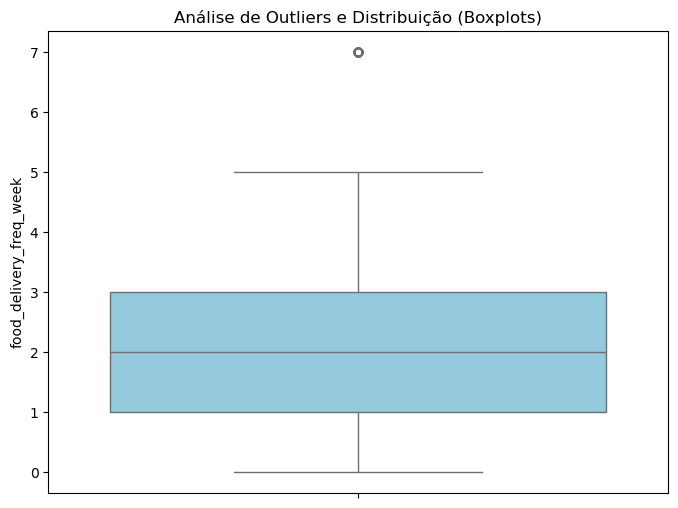

In [41]:
# Boxplot para análise de outliers e distribuição das variáveis numéricas
plt.figure(figsize=(8, 6))
sns.boxplot(data=usuarios, y='food_delivery_freq_week', color='skyblue')
plt.title('Análise de Outliers e Distribuição (Boxplots)')
plt.ylabel('food_delivery_freq_week')
plt.show()

**Análise:** \
"A análise do boxplot indica que a variável apresenta uma distribuição bem equilibrada. Observa-se a presença de um único outlier (valor atípico) no valor de 7 pedidos por semana, o qual reflete um comportamento real e perfeitamente possível de um usuário com alta frequência de consumo

## 4ª União e tratamento extra das bases unificadas

In [49]:
# União dos dados
# Primeira união: Concetar as sessões ás tentativas (Chave: session_id)
sessions_attempts = pd.merge(
    sessao,
    palavritas,
    on='session_id',
    how='inner'
)

# Segunda união: Adicionar o perfil do usuário ao resultado anterior (Chave: user_id)
base_unificada = pd.merge(
    sessions_attempts,
    usuarios,
    on='user_id',
    how='left'
)

# Exibe o formato final da base unificada
print(f"Formato final da base: {base_unificada.shape[0]} linhas e {base_unificada.shape[1]} colunas.")

Formato final da base: 155416 linhas e 31 colunas.


In [52]:
# Exibir todas as primeiras linhas do DataFrame para verificar os dados carregados
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
base_unificada.head()

,session_id,user_id,word,word_date,attempts,result,time_to_complete_sec,device,session_hour,streak_day,played_next_day,newsletter_open_before_game,active_d30,word_day_num,attempt_number,guess,correct_letters,correct_positions,age_range,state,salary_range,job_role,sector,company_size,orders_food_delivery,food_delivery_freq_week,food_delivery_platform,primary_device,plays_other_word_games,typical_play_time,newsletter_subscriber
0,ab38635a07ede4246661,697e9e150e91bb76,TEMPO,2026-02-08,1,Win,449,Android,20,2,False,False,False,8,1,TEMPO,0,5,35-44,BA,acima de R$10k,Analista,Finanças,Média,True,2.0,Nenhum,Android,False,Night,True
1,67d40a22cba1a16fd2c5,d7f63dda905adaec,FALHA,2026-05-08,6,Lose,232,iOS,19,1,True,False,False,8,1,NOVAS,1,0,35-44,PE,R$4k-R$6k,Analista,Tech,Grande,True,7.0,Rappi,iOS,True,Night,True
2,67d40a22cba1a16fd2c5,d7f63dda905adaec,FALHA,2026-05-08,6,Lose,232,iOS,19,1,True,False,False,8,2,OUVIR,0,0,35-44,PE,R$4k-R$6k,Analista,Tech,Grande,True,7.0,Rappi,iOS,True,Night,True
3,67d40a22cba1a16fd2c5,d7f63dda905adaec,FALHA,2026-05-08,6,Lose,232,iOS,19,1,True,False,False,8,3,NOVAS,1,0,35-44,PE,R$4k-R$6k,Analista,Tech,Grande,True,7.0,Rappi,iOS,True,Night,True
4,67d40a22cba1a16fd2c5,d7f63dda905adaec,FALHA,2026-05-08,6,Lose,232,iOS,19,1,True,False,False,8,4,VAPOR,0,1,35-44,PE,R$4k-R$6k,Analista,Tech,Grande,True,7.0,Rappi,iOS,True,Night,True


**Atribuições das variáveis:** \
session_id = Identificador único da sessão de jogo; \
user_id = Identificador anonimizado do usuário; \
word = Palavra do desafio do dia; \
word_date = Data do desafio; \
attempts = Número de tentativas (1–6); \
result = Resultado: win / lose; \
time_to_complete_sec = Tempo de jogo em segundos; \
device = Dispositivo usado; \
session_hour = Hora do dia em que jogou (0–23); \
streak_day = Dia atual da sequência do usuário; \
played_next_day = Se o usuário voltou a jogar no dia seguinte; \
newsletter_open_before_game = Se abriu a newsletter antes de jogar naquele dia; \
active_d30 = Se o usuário estava ativo 30 dias após essa sessão; \
word_day_num = Número do dia do mês (1-31) *Nova variável;\
attempt_number = Número da tentativa; \
guess = Palavra digitada; \
correct_letters = Letras certas em posição errada; \
correct_positions = Letras certas na posição certa; \
age_range = Faixa etária; \
state = Estado (UF); \
salary_range = Faixa salarial; \
job_role = Cargo; \
sector = Setor de trabalho; \
company_size = Porte da empresa; \
orders_food_delivery = Se pede comida por app; \
food_delivery_freq_week = Quantas vezes por semana; \
food_delivery_platform = Plataforma usada; \
primary_device = Dispositivo principal; \
plays_other_word_games = Se joga outros jogos de palavras; \
typical_play_time = Período típico de jogo (morning/afternoon/night); \
newsletter_subscriber = Se é assinante da newsletter.

### A) Análise dos tipos de dados, se possuem dados nulos e a quantidade

In [53]:
# Exibir informações sobre o DataFrame, incluindo tipos de dados e contagem de valores não nulos
base_unificada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155416 entries, 0 to 155415
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   session_id                   155416 non-null  object        
 1   user_id                      155416 non-null  object        
 2   word                         155416 non-null  object        
 3   word_date                    155416 non-null  datetime64[ns]
 4   attempts                     155416 non-null  int64         
 5   result                       155416 non-null  object        
 6   time_to_complete_sec         155416 non-null  int64         
 7   device                       155416 non-null  object        
 8   session_hour                 155416 non-null  int64         
 9   streak_day                   155416 non-null  int64         
 10  played_next_day              155416 non-null  bool          
 11  newsletter_open_before_gam

**Análise:** \
A maior parte das variáveis da base unificada já está formatada corretamente e sem dados nulos. Os únicos problemas de formato e de dados nulos vêm do arquivo "user_profile.csv", que será analisado de perto e tratado logo abaixo.

### Análise, tratamento e conversão das variáveis "orders_food_delivery", "plays_other_word_games" e "newsletter_subscriber" para o tipo booleanos

In [56]:
# Conferência dos tipos de dados das variáveis
b1 = base_unificada['orders_food_delivery'].unique()
b2 = base_unificada['plays_other_word_games'].unique()
b3 = base_unificada['newsletter_subscriber'].unique()

print(f'Valores únicos da variável "orders_food_delivery":\n {b1}\n')
print(f'Valores únicos da variável "plays_other_word_games":\n {b2}\n')
print(f'Valores únicos da variável "newsletter_subscriber":\n {b3}\n')

Valores únicos da variável "orders_food_delivery":
 [True nan]

Valores únicos da variável "plays_other_word_games":
 [False True nan]

Valores únicos da variável "newsletter_subscriber":
 [True False nan]



**Análise:** \
A análise revela que essas variáveis estão configuradas como o tipo object devido à presença de valores ausentes. Para convertê-las para o tipo booleano, é necessário realizar o tratamento dos nulos antes da conversão.

Como cada variável exige uma abordagem específica, observa-se que "orders_food_delivery" possui apenas registros True e NaN. A ausência completa de valores falsos sugere uma inconsistência na coleta ou na unificação dos dados. Portanto, os valores nulos serão substituídos por False. Já as variáveis "plays_other_word_games" e "newsletter_subscriber" apresentam valores True, False e NaN, indicando que os usuários apenas optaram por não responder. Seguindo princípios estatísticos para variáveis categóricas, esses valores nulos serão substituídos pela moda (o valor mais frequente da distribuição).

In [57]:
# Substituição de valores nulos da variável "orders_food_delivery" por False
base_unificada['orders_food_delivery'] = base_unificada['orders_food_delivery'].fillna('False')

# Calculo da mediana convertendo temporariamente para número (True=1, False=0)
mediana_games_num = base_unificada['plays_other_word_games'].astype(float).median()
mediana_news_num = base_unificada['newsletter_subscriber'].astype(float).median()

# Convertendo o número da mediana de volta para Booleano (True se for >= 0.5, False se for < 0.5)
mediana_games_bool = bool(mediana_games_num)
mediana_news_bool = bool(mediana_news_num)

# Substituição de valores nulos das variáveis "plays_other_word_games" e "newsletter_subscriber" pela mediana
base_unificada['plays_other_word_games'] = base_unificada['plays_other_word_games'].fillna(mediana_games_bool)
base_unificada['newsletter_subscriber'] = base_unificada['newsletter_subscriber'].fillna(mediana_news_bool)

C:\Users\nneto\AppData\Local\Temp\ipykernel_20028\3425047827.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base_unificada['plays_other_word_games'] = base_unificada['plays_other_word_games'].fillna(mediana_games_bool)
C:\Users\nneto\AppData\Local\Temp\ipykernel_20028\3425047827.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base_unificada['newsletter_subscriber'] = base_unificada['newsletter_subscriber'].fillna(mediana_news_bool)


In [58]:
# Conversão das variáveis para booleano
base_unificada['orders_food_delivery'] = base_unificada['orders_food_delivery'].astype(bool)
base_unificada['plays_other_word_games'] = base_unificada['plays_other_word_games'].astype(bool)
base_unificada['newsletter_subscriber'] = base_unificada['newsletter_subscriber'].astype(bool)

In [ ]:
# Verificação do tratamento e conversão das variáveis para o tipo booleano
base_unificada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155416 entries, 0 to 155415
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   session_id                   155416 non-null  object        
 1   user_id                      155416 non-null  object        
 2   word                         155416 non-null  object        
 3   word_date                    155416 non-null  datetime64[ns]
 4   attempts                     155416 non-null  int64         
 5   result                       155416 non-null  object        
 6   time_to_complete_sec         155416 non-null  int64         
 7   device                       155416 non-null  object        
 8   session_hour                 155416 non-null  int64         
 9   streak_day                   155416 non-null  int64         
 10  played_next_day              155416 non-null  bool          
 11  newsletter_open_before_gam

### Análise, tartamento e conversão da variável "food_delivery_freq_week" para o tipo inteiro

In [62]:
# Conferência dos tipos de dados das variáveis
base_unificada['food_delivery_freq_week'].unique()

array([ 2.,  7.,  3., nan,  0.,  5.,  1.])

In [ ]:
# Conferência da quantidade de dados nulos da variável "food_delivery_freq_week"
quantidade_nulos = base_unificada['food_delivery_freq_week'].isnull().sum()

print(f'Quantidade de valores nulos da variável "food_delivery_freq_week": {quantidade_nulos}')

Quantidade de valores nulos da variável "food_delivery_freq_week": 0
Percentual de valores nulos da variável "food_delivery_freq_week": 0.00%


In [68]:
# Conferência do percentual de dados nulos da variável "food_delivery_freq_week"
percentual_nulos = base_unificada['food_delivery_freq_week'].isnull().mean() * 100

print(f'Percentual de valores nulos da variável "food_delivery_freq_week": {percentual_nulos:.2f}%')

Percentual de valores nulos da variável "food_delivery_freq_week": 0.00%


**Análise:** \
Para realizar a conversão da variável para o tipo inteiro — que é o formato padrão —, é necessário, assim como explicado anteriormente, tratar os valores nulos primeiro. 

A análise revela que o volume de dados omitidos é bastante expressivo, atingindo 32,84% da base. Essa alta proporção exige uma estratégia de tratamento que evite a perda de registros e impeça o enviesamento dos dados. Diante disso, a escolha mais adequada não é a imputação pela média ou pela mediana, mas sim a substituição pelo valor 0. Isso se justifica porque a ausência de registro indica, na maioria das vezes, a não ocorrência do evento. Atribuir a média inflaria artificialmente o engajamento geral da base, enquanto o zero preserva a realidade comportamental desses usuários e permite a conversão segura para o tipo numérico inteiro.

In [66]:
# Substituição dos valores nulos por 0
base_unificada['food_delivery_freq_week'] = base_unificada['food_delivery_freq_week'].fillna(0)

# Conversão da variável para o tipo inteiro
base_unificada['food_delivery_freq_week'] = base_unificada['food_delivery_freq_week'].astype(int)

In [69]:
# Verificação do tratamento e conversão da variável para o tipo inteiro
base_unificada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155416 entries, 0 to 155415
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   session_id                   155416 non-null  object        
 1   user_id                      155416 non-null  object        
 2   word                         155416 non-null  object        
 3   word_date                    155416 non-null  datetime64[ns]
 4   attempts                     155416 non-null  int64         
 5   result                       155416 non-null  object        
 6   time_to_complete_sec         155416 non-null  int64         
 7   device                       155416 non-null  object        
 8   session_hour                 155416 non-null  int64         
 9   streak_day                   155416 non-null  int64         
 10  played_next_day              155416 non-null  bool          
 11  newsletter_open_before_gam

### B) Análise e padronização do preenchimento das variáveis

Mantendo o padrão adotado, a análise e a padronização nesta etapa focarão exclusivamente nas variáveis do tipo object da base de dados "user_profile.csv" que apresentam valores nulos. O objetivo é realizar o tratamento adequado desses registros ausentes antes de prosseguir.

In [74]:
# Lista com as variáveis que serão analisadas
usuarios_analise = base_unificada[[
    'age_range', 'state', 'salary_range', 'job_role',
    'sector', 'company_size', 'food_delivery_platform', 
    'primary_device', 'typical_play_time'
]]

# Verificação e exibição da padronização do preenchimento dos valores das variáveis
for x in usuarios_analise.columns:
    print(f'Valores únicos da variável "{x}":')
    print(usuarios_analise[x].unique(), '\n')

Valores únicos da variável "age_range":
['35-44' 'Não informado' '25-34' nan '45+' '18-24'] 

Valores únicos da variável "state":
['BA' 'PE' 'MS' nan 'MA' 'SP' 'RS' 'MT' 'PB' 'ES' 'PR' 'AM' 'DF' 'CE' 'RJ'
 'SE' 'GO' 'SC' 'MG' 'AL' 'RN'] 

Valores únicos da variável "salary_range":
['acima de R$10k' 'R$4k-R$6k' 'R$2k-R$4k' nan 'até R$2k' 'Não informado'
 'R$6k-R$10k'] 

Valores únicos da variável "job_role":
['Analista' 'Diretor' 'Diretor Sênior' nan 'Coordenador'
 'Desenvolvedor de Dados' 'Gerente' 'Consultor' 'Estudante'
 'Desenvolvedor' 'Designer' 'Professor' 'Professor Sênior'
 'Coordenador Sênior' 'Engenheiro' 'Designer Sênior' 'Gerente Sênior'
 'Consultor Sênior' 'Desenvolvedor Sênior' 'Analista de Dados'
 'Engenheiro Sênior' 'Professor de Dados' 'Gerente de Dados'
 'Estudante de Dados' 'Estudante Sênior' 'Consultor de Dados'
 'Engenheiro de Dados' 'Diretor de Dados' 'Coordenador de Dados'
 'Analista Sênior' 'Designer de Dados'] 

Valores únicos da variável "sector":
['Finanças' '

**Análise:** \
Constatou-se a ausência de erros de preenchimento nas variáveis, o que demonstra a eficácia das correções realizadas previamente na base de dados. Contudo, foram identificados valores nulos — uma ocorrência compreensível devido ao processo de unificação das bases. Esse cenário será detalhado e tratado adequadamente a seguir.

### C) Análise mais precisa de valores nulos, faltantes e outliers (valores discrepantes)

In [75]:
# Conferência de valores nulos
base_unificada.isnull().sum()

session_id                         0
user_id                            0
word                               0
word_date                          0
attempts                           0
result                             0
time_to_complete_sec               0
device                             0
session_hour                       0
streak_day                         0
played_next_day                    0
newsletter_open_before_game        0
active_d30                         0
word_day_num                       0
attempt_number                     0
guess                              0
correct_letters                    0
correct_positions                  0
age_range                      51038
state                          51038
salary_range                   51038
job_role                       51038
sector                         51038
company_size                   51038
orders_food_delivery               0
food_delivery_freq_week            0
food_delivery_platform         51038
p

In [76]:
# Conferência do percentual de valores nulos
base_unificada.isnull().mean() * 100

session_id                      0.000000
user_id                         0.000000
word                            0.000000
word_date                       0.000000
attempts                        0.000000
result                          0.000000
time_to_complete_sec            0.000000
device                          0.000000
session_hour                    0.000000
streak_day                      0.000000
played_next_day                 0.000000
newsletter_open_before_game     0.000000
active_d30                      0.000000
word_day_num                    0.000000
attempt_number                  0.000000
guess                           0.000000
correct_letters                 0.000000
correct_positions               0.000000
age_range                      32.839605
state                          32.839605
salary_range                   32.839605
job_role                       32.839605
sector                         32.839605
company_size                   32.839605
orders_food_deli

**Análise:** \
O volume de valores nulos entre essas variáveis é idêntico, representando 32,83% dos dados. Em sua maioria, esses registros ausentes serão substituídos por 'Não informado'. Cabe destacar a variável "food_delivery_platform", que já apresenta a opção "Nenhum". Essa resposta possui um significado de negócio distinto dos valores nulos, pois indica explicitamente que o usuário não utiliza plataformas de delivery. Portanto, para manter essa distinção, apenas os campos nulos serão mapeados como "Não informado", preservando os registros preenchidos como "Nenhum".

**Hipótese:** \
O fato de esse percentual de nulos ser exatamente igual e ocorrer simultaneamente nas mesmas linhas sugere uma hipótese analítica forte: esses usuários provavelmente jogaram o quiz, mas não possuem um perfil demográfico cadastrado no sistema. Essa correlação e o impacto do comportamento desses usuários sem cadastro serão explorados detalhadamente mais à frente, durante a Análise Exploratória de Dados (EDA).

In [77]:
# Lista da variáveis com valores nulos
usuarios_nulos = base_unificada[[
    'age_range', 'state', 'salary_range', 'job_role',
    'sector', 'company_size', 'food_delivery_platform', 
    'primary_device', 'typical_play_time'
]]

# Substituição dos valores nulos por "Não informado"
base_unificada = usuarios_nulos.fillna('Não informado')
base_unificada = usuarios_nulos.fillna('Não informado')

In [78]:
# Verificação da substituição dos valores nulos das variáveis
base_unificada.isnull().sum()

age_range                 0
state                     0
salary_range              0
job_role                  0
sector                    0
company_size              0
food_delivery_platform    0
primary_device            0
typical_play_time         0
dtype: int64

## SALVAR DADOS TRATADOS

A base de dados será salva de duas formas: tanto individualmente quanto unificada. Portanto, as bases serão salvas individualmente e, em seguida, integradas por meio de suas variáveis-chave para gerar um arquivo único. Essa estratégia visa expandir as possibilidades de análise e garantir maior praticidade durante a Análise Exploratória de Dados (EDA).

In [229]:
# Salvar base de dados "palavritas_sessions.csv"
sessao.to_csv('tratado_palavritas_sessions.csv', index=False, encoding='utf-8')

In [210]:
# Salvar base de dados "palavritas_attempts.csv"
palavritas.to_csv('tratado_palavritas_attempts.csv', index=False, encoding='utf-8')

In [212]:
# Salvar base de dados "user_profile.csv"
usuarios.to_csv('tratamento_user_profile.csv', index=False, encoding='utf-8')

In [79]:
# Save das bases unificadas para a etapa de Análise Exploratória de Dados (AED)
base_unificada.to_csv('base_palavritas_unificada.csv', index=False, encoding='utf-8')